# Dataset Alignment Inspector

Quick visual check that `data_imgs` frames align with annotation bboxes.

What this notebook does:
- Loads sequence index CSV (`train_dataframe.csv` or `.partial`)
- Randomly samples sequence + (template, search) frame pair
- Plots full frames with GT bbox
- Plots extracted search crop with target bbox projected into crop coordinates


In [11]:
from pathlib import Path
import random
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'utils').exists():
    # If launched from notebooks/ folder in some IDEs
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils.dataset import TrackingSequence
from utils.utils import extend_bbox, get_extended_crop

print('Repo root:', REPO_ROOT)

Repo root: /home/moha/SiamRAM


In [12]:
# Config
CSV_CANDIDATES = [
    REPO_ROOT / 'data' / 'train_dataframe.csv',
    REPO_ROOT / 'data' / 'train_dataframe.csv.partial',
]

TEMPLATE_SIZE = 128
SEARCH_SIZE = 256
TEMPLATE_OFFSET = 0.2
SEARCH_CONTEXT = 2.0
MAX_FRAME_GAP = 130
SEED = 42

rng = random.Random(SEED)

In [13]:
def pick_csv():
    for p in CSV_CANDIDATES:
        if p.exists():
            return p
    raise FileNotFoundError(f'No CSV found in: {CSV_CANDIDATES}')

csv_path = pick_csv()
df = pd.read_csv(csv_path)
print('CSV:', csv_path)
print('Rows:', len(df))
display(df.head(10))

CSV: /home/moha/SiamRAM/data/train_dataframe.csv
Rows: 253


,seq_path,img_path,annot_path,start_idx,end_idx,n_frames,ann_len,H,W,class,dataset,frame_pattern
0,/app/data_imgs/dataset1/Car_video_2/img,/app/data_imgs/dataset1/Car_video_2/img,/app/data/dataset1/Car_video_2/annotation.txt,1,678,678,678,1168,778,Car_video,dataset1,{:08d}.jpg
1,/app/data_imgs/dataset1/Car_video_3/img,/app/data_imgs/dataset1/Car_video_3/img,/app/data/dataset1/Car_video_3/annotation.txt,1,223,223,223,1440,2732,Car_video,dataset1,{:08d}.jpg
2,/app/data_imgs/dataset1/horse_4/img,/app/data_imgs/dataset1/horse_4/img,/app/data/dataset1/horse_4/annotation.txt,1,235,235,235,2160,3840,horse,dataset1,{:08d}.jpg
3,/app/data_imgs/dataset1/horse_6/img,/app/data_imgs/dataset1/horse_6/img,/app/data/dataset1/horse_6/annotation.txt,1,448,448,448,1024,576,horse,dataset1,{:08d}.jpg
4,/app/data_imgs/dataset1/motorcycle/img,/app/data_imgs/dataset1/motorcycle/img,/app/data/dataset1/motorcycle/annotation.txt,1,801,801,801,960,540,motorcycle,dataset1,{:08d}.jpg
5,/app/data_imgs/dataset1/person_4/img,/app/data_imgs/dataset1/person_4/img,/app/data/dataset1/person_4/annotation.txt,1,602,602,602,1440,2560,person,dataset1,{:08d}.jpg
6,/app/data_imgs/dataset1/plane/img,/app/data_imgs/dataset1/plane/img,/app/data/dataset1/plane/annotation.txt,1,358,358,358,1024,576,plane,dataset1,{:08d}.jpg
7,/app/data_imgs/dataset1/surfer/img,/app/data_imgs/dataset1/surfer/img,/app/data/dataset1/surfer/annotation.txt,1,150,150,150,1440,2560,surfer,dataset1,{:08d}.jpg
8,/app/data_imgs/dataset1/volleyball/img,/app/data_imgs/dataset1/volleyball/img,/app/data/dataset1/volleyball/annotation.txt,1,2088,2088,2088,2160,3840,volleyball,dataset1,{:08d}.jpg
9,/app/data_imgs/dataset2/Animal1/img,/app/data_imgs/dataset2/Animal1/img,/app/data/dataset2/Animal1/annotation.txt,1,147,147,147,720,1280,Animal,dataset2,{:08d}.jpg


In [14]:
# Remap Docker-style /app paths to local machine paths when needed
from pathlib import Path

def remap_one_path(path_value, repo_root: Path):
    p = str(path_value)
    if not p:
        return p
    p = p.strip()

    # Already valid on this machine
    if Path(p).exists():
        return p

    # Docker path -> host repo path
    if p.startswith('/app/'):
        cand = (repo_root / p[len('/app/'):]).resolve()
        if cand.exists():
            return str(cand)

    return p

def remap_dataframe_paths(df_in: pd.DataFrame, repo_root: Path = REPO_ROOT) -> pd.DataFrame:
    df_out = df_in.copy()
    for col in ('seq_path', 'img_path', 'annot_path'):
        if col not in df_out.columns:
            continue
        before = df_out[col].astype(str)
        after = before.map(lambda x: remap_one_path(x, repo_root))
        df_out[col] = after
        changed = int((before != after).sum())
        missing = int((~after.map(lambda x: Path(str(x)).exists())).sum())
        print(f'{col}: remapped={changed}, missing_after_remap={missing}')
    return df_out

df = remap_dataframe_paths(df, REPO_ROOT)
display(df.head(2))


seq_path: remapped=253, missing_after_remap=0
img_path: remapped=253, missing_after_remap=0
annot_path: remapped=253, missing_after_remap=0


,seq_path,img_path,annot_path,start_idx,end_idx,n_frames,ann_len,H,W,class,dataset,frame_pattern
0,/home/moha/SiamRAM/data_imgs/dataset1/Car_vide...,/home/moha/SiamRAM/data_imgs/dataset1/Car_vide...,/home/moha/SiamRAM/data/dataset1/Car_video_2/a...,1,678,678,678,1168,778,Car_video,dataset1,{:08d}.jpg
1,/home/moha/SiamRAM/data_imgs/dataset1/Car_vide...,/home/moha/SiamRAM/data_imgs/dataset1/Car_vide...,/home/moha/SiamRAM/data/dataset1/Car_video_3/a...,1,223,223,223,1440,2732,Car_video,dataset1,{:08d}.jpg


In [15]:
def load_rgb(path: str):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def draw_bbox(img, bbox, color=(0, 255, 0), thickness=2):
    out = img.copy()
    x, y, w, h = [int(round(v)) for v in bbox]
    cv2.rectangle(out, (x, y), (x + w, y + h), color, thickness)
    return out

def sample_valid_pair(df_in, rng_local, max_tries=200):
    for _ in range(max_tries):
        row = df_in.sample(1, random_state=rng_local.randint(0, 10_000_000)).iloc[0]
        seq = TrackingSequence(row.to_dict())

        start_idx = int(row['start_idx'])
        end_idx = int(row['end_idx'])
        if end_idx - start_idx < 2:
            continue

        t_idx = seq.sample_valid_frame(rng_local, lower_end=start_idx, upper_end=end_idx - 1)
        if t_idx is None:
            continue

        lo = t_idx + 1
        hi = min(end_idx, t_idx + MAX_FRAME_GAP)
        if lo > hi:
            continue

        s_idx = seq.sample_valid_frame(rng_local, lower_end=lo, upper_end=hi)
        if s_idx is None:
            continue

        t_bbox = seq.get_bbox(t_idx)
        s_bbox = seq.get_bbox(s_idx)
        if not seq.is_valid_bbox(t_bbox) or not seq.is_valid_bbox(s_bbox):
            continue

        t_path = seq.frame_path(t_idx)
        s_path = seq.frame_path(s_idx)
        if not Path(t_path).exists() or not Path(s_path).exists():
            continue

        return row, seq, t_idx, s_idx, t_bbox, s_bbox, t_path, s_path

    raise RuntimeError('Could not sample a valid pair. Check CSV paths/frames.')

In [16]:
def inspect_one_sample(df_in, rng_local):
    row, seq, t_idx, s_idx, t_bbox, s_bbox, t_path, s_path = sample_valid_pair(df_in, rng_local)

    t_img = load_rgb(t_path)
    s_img = load_rgb(s_path)

    t_full = draw_bbox(t_img, t_bbox, color=(0, 255, 0), thickness=2)
    s_full = draw_bbox(s_img, s_bbox, color=(0, 255, 0), thickness=2)

    t_context = extend_bbox(
        t_bbox,
        offset=TEMPLATE_OFFSET,
        image_width=t_img.shape[1],
        image_height=t_img.shape[0],
    )
    t_crop, t_bbox_in_crop, _ = get_extended_crop(
        image=t_img,
        bbox=t_bbox,
        context=t_context,
        crop_size=TEMPLATE_SIZE,
    )

    s_context = extend_bbox(
        s_bbox,
        offset=SEARCH_CONTEXT,
        image_width=s_img.shape[1],
        image_height=s_img.shape[0],
    )
    s_crop, s_bbox_in_crop, _ = get_extended_crop(
        image=s_img,
        bbox=s_bbox,
        context=s_context,
        crop_size=SEARCH_SIZE,
        padding_value=np.mean(s_img, axis=(0, 1)),
    )

    t_crop_vis = draw_bbox(t_crop, t_bbox_in_crop, color=(255, 0, 0), thickness=2)
    s_crop_vis = draw_bbox(s_crop, s_bbox_in_crop, color=(255, 0, 0), thickness=2)

    print(f"dataset={row['dataset']} class={row['class']}")
    print(f"template idx={t_idx} path={t_path}")
    print(f"search   idx={s_idx} path={s_path}")
    print('template bbox (full):', np.array(t_bbox, dtype=float))
    print('search   bbox (full):', np.array(s_bbox, dtype=float))
    print('search bbox (in crop):', np.array(s_bbox_in_crop, dtype=float))

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    axes[0, 0].imshow(t_full)
    axes[0, 0].set_title('Template Frame + GT BBox')
    axes[0, 1].imshow(s_full)
    axes[0, 1].set_title('Search Frame + GT BBox')
    axes[1, 0].imshow(t_crop_vis)
    axes[1, 0].set_title('Template Crop + Projected BBox')
    axes[1, 1].imshow(s_crop_vis)
    axes[1, 1].set_title('Search Crop + Projected BBox')

    for ax in axes.ravel():
        ax.axis('off')
    plt.tight_layout()
    plt.show()


dataset=dataset5 class=car
template idx=62 path=/home/moha/SiamRAM/data_imgs/dataset5/car13/img/00000062.jpg
search   idx=124 path=/home/moha/SiamRAM/data_imgs/dataset5/car13/img/00000124.jpg
template bbox (full): [706. 342.  14.   8.]
search   bbox (full): [688. 117.  11.   7.]
search bbox (in crop): [102. 102.  51.  51.]


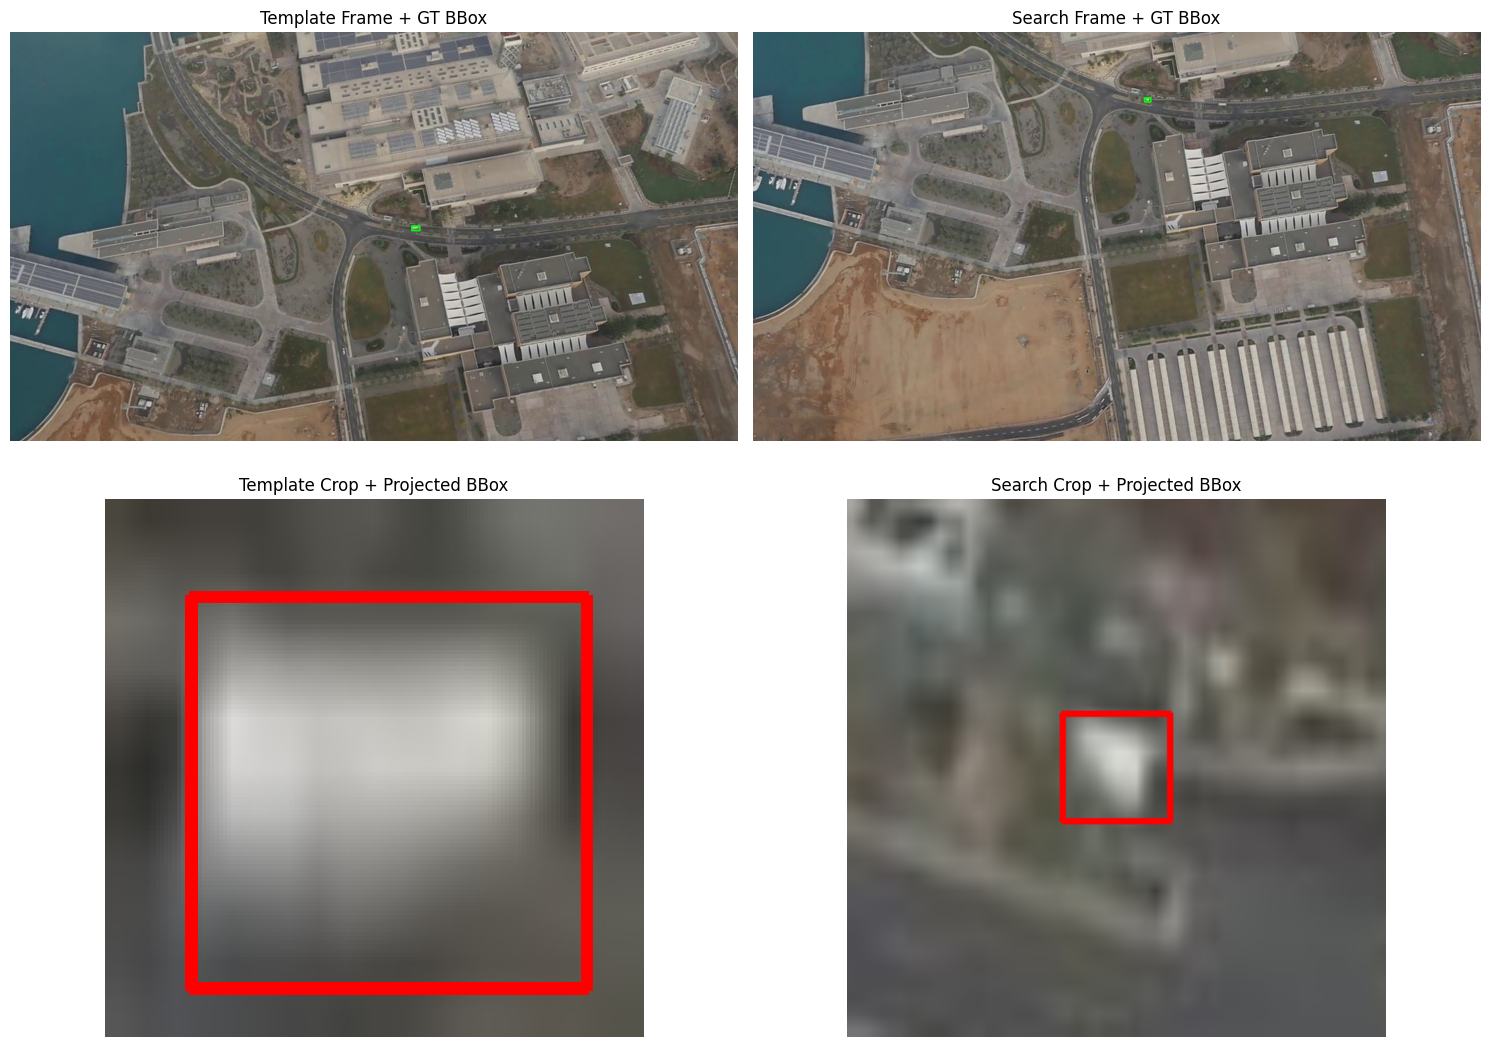

In [25]:
# Run this cell repeatedly for random checks
inspect_one_sample(df, rng)

## Negative Sampling Audit (with YOLO class hints)

These cells inspect how `UAVTrackingDataset` builds negatives, including:
- strategy usage (`cross_seq`, `shifted_hard`, `shifted`, `distractor`)
- whether `yolo_target_class` is present and used
- how often cross-sequence negatives are sampled from the same class


In [18]:
import types
import yaml

from utils.dataset import UAVTrackingDataset

CSV_NEG_CANDIDATES = [
    REPO_ROOT / 'data' / 'train_dataframe_with_yolo.csv',
    REPO_ROOT / 'data' / 'train_dataframe.csv',
    REPO_ROOT / 'data' / 'train_dataframe.csv.partial',
]

def pick_neg_csv():
    for p in CSV_NEG_CANDIDATES:
        if p.exists():
            return p
    raise FileNotFoundError(f'No CSV found in: {CSV_NEG_CANDIDATES}')

neg_csv = pick_neg_csv()
neg_df = pd.read_csv(neg_csv)
if 'remap_dataframe_paths' in globals():
    neg_df = remap_dataframe_paths(neg_df, REPO_ROOT)

cfg = yaml.safe_load((REPO_ROOT / 'config' / 'training_config.yaml').read_text())
tracking_cfg = dict(cfg['tracking'])

print('Negative-audit CSV:', neg_csv)
print('Rows:', len(neg_df))
print('Has yolo_target_class column:', 'yolo_target_class' in neg_df.columns)
if 'yolo_target_class' in neg_df.columns:
    valid_yolo = neg_df['yolo_target_class'].astype(str).str.strip().replace({'nan': ''}).ne('').sum()
    print(f'Rows with non-empty yolo_target_class: {valid_yolo}/{len(neg_df)}')

neg_dataset = UAVTrackingDataset(
    dataframe=neg_df,
    tracking_config=tracking_cfg,
    num_samples=1000,
    neg_ratio=1.0,
    seed=42,
)

# --- Instrumentation hooks for debug-only notebook auditing ---
neg_dataset._dbg_samples = []
neg_dataset._dbg_last_strategy = None
neg_dataset._dbg_last_src = {}

orig_sample_src = neg_dataset._sample_negative_source_sequence
orig_cross = neg_dataset._build_cross_sequence_negative_search
orig_shifted = neg_dataset._build_shifted_negative_search
orig_distractor = neg_dataset._build_distractor_negative_search
orig_pack = neg_dataset._pack

def sample_src_wrap(self, anchor_seq):
    src = orig_sample_src(anchor_seq)
    anchor_cls = self._sequence_class_key(anchor_seq.cls)
    src_cls = self._sequence_class_key(src.cls) if src is not None else ''
    self._dbg_last_src = {
        'anchor_cls': anchor_cls,
        'source_cls': src_cls,
        'same_class': bool(src is not None and anchor_cls == src_cls),
    }
    return src

def cross_wrap(self, anchor_seq):
    crop = orig_cross(anchor_seq)
    if crop is not None:
        self._dbg_last_strategy = 'cross_seq'
    return crop

def shifted_wrap(self, seq, frame_idx, target_bbox, hard_mode=True):
    crop = orig_shifted(seq, frame_idx, target_bbox, hard_mode=hard_mode)
    if crop is not None:
        self._dbg_last_strategy = 'shifted_hard' if hard_mode else 'shifted'
    return crop

def distractor_wrap(self, seq, frame_idx, target_bbox):
    crop = orig_distractor(seq, frame_idx, target_bbox)
    if crop is not None:
        self._dbg_last_strategy = 'distractor'
    return crop

def pack_wrap(self, template, dynamic_template, search, dynamic_search, cls_label, bbox_label, iou_label, reg_weight, is_positive, path=None):
    if not is_positive:
        rec = {'strategy': self._dbg_last_strategy}
        rec.update(self._dbg_last_src if isinstance(self._dbg_last_src, dict) else {})
        self._dbg_samples.append(rec)
    return orig_pack(template, dynamic_template, search, dynamic_search, cls_label, bbox_label, iou_label, reg_weight, is_positive, path=path)

neg_dataset._sample_negative_source_sequence = types.MethodType(sample_src_wrap, neg_dataset)
neg_dataset._build_cross_sequence_negative_search = types.MethodType(cross_wrap, neg_dataset)
neg_dataset._build_shifted_negative_search = types.MethodType(shifted_wrap, neg_dataset)
neg_dataset._build_distractor_negative_search = types.MethodType(distractor_wrap, neg_dataset)
neg_dataset._pack = types.MethodType(pack_wrap, neg_dataset)

print('Instrumentation installed.')

def robust_negative_sample(ds, max_tries=80):
    """Sample a negative robustly by skipping broken rows/files."""
    last_exc = None
    for _ in range(max_tries):
        try:
            return ds._negative_sample()
        except (FileNotFoundError, RuntimeError, ValueError, OSError) as exc:
            last_exc = exc
            continue
    if last_exc is not None:
        print(f"[warn] robust_negative_sample fallback after retries: {last_exc}")
    return ds._dummy_negative()

print('robust_negative_sample helper ready.')


seq_path: remapped=103, missing_after_remap=0
img_path: remapped=103, missing_after_remap=0
annot_path: remapped=103, missing_after_remap=0
Negative-audit CSV: /home/moha/SiamRAM/data/train_dataframe_with_yolo.csv
Rows: 103
Has yolo_target_class column: True
Rows with non-empty yolo_target_class: 103/103
[Dataset] 103 sequences | sources={'dataset5': 90, 'dataset4': 13} | num_samples=1000 | neg_ratio=100% | cross_seq_neg=45% | same_class_neg=70% | occlusion_aug=35% | template_size=128 | instance_size=256 | score_size=16
Instrumentation installed.
robust_negative_sample helper ready.


In [19]:
N_AUDIT = 300
audit_samples = []
fail_count = 0
for _ in range(N_AUDIT):
    sample = robust_negative_sample(neg_dataset)
    if not bool(sample['is_positive']):
        audit_samples.append(sample)
    else:
        fail_count += 1

audit_df = pd.DataFrame(neg_dataset._dbg_samples)
print(f'Generated negatives: {len(audit_samples)}')
print(f'Fallback/dummy samples: {fail_count}')
print('is_positive unique:', {bool(s['is_positive']) for s in audit_samples})

if not audit_df.empty:
    print('\nStrategy distribution:')
    display(audit_df['strategy'].value_counts(dropna=False).to_frame('count'))

    cross_df = audit_df[audit_df['strategy'] == 'cross_seq']
    if not cross_df.empty:
        same_rate = 100.0 * cross_df['same_class'].fillna(False).mean()
        print(f'Cross-seq same-class rate: {same_rate:.1f}%')
        print('Top cross-seq class pairs:')
        pairs = (cross_df[['anchor_cls','source_cls']]
                 .astype(str)
                 .value_counts()
                 .head(10)
                 .rename('count')
                 .to_frame())
        display(pairs)
else:
    print('No debug samples recorded.')


Generated negatives: 300
Fallback/dummy samples: 0
is_positive unique: {False}

Strategy distribution:


,count
strategy,
cross_seq,141
shifted_hard,108
distractor,51


Cross-seq same-class rate: 80.1%
Top cross-seq class pairs:


count
anchor_cls source_cls       
person     person         58
car        car            30
boat       boat           10
truck      truck           7
car        person          4
           boat            3
uav        uav             3
person     car             3
uav1       person          2
uav        person          2

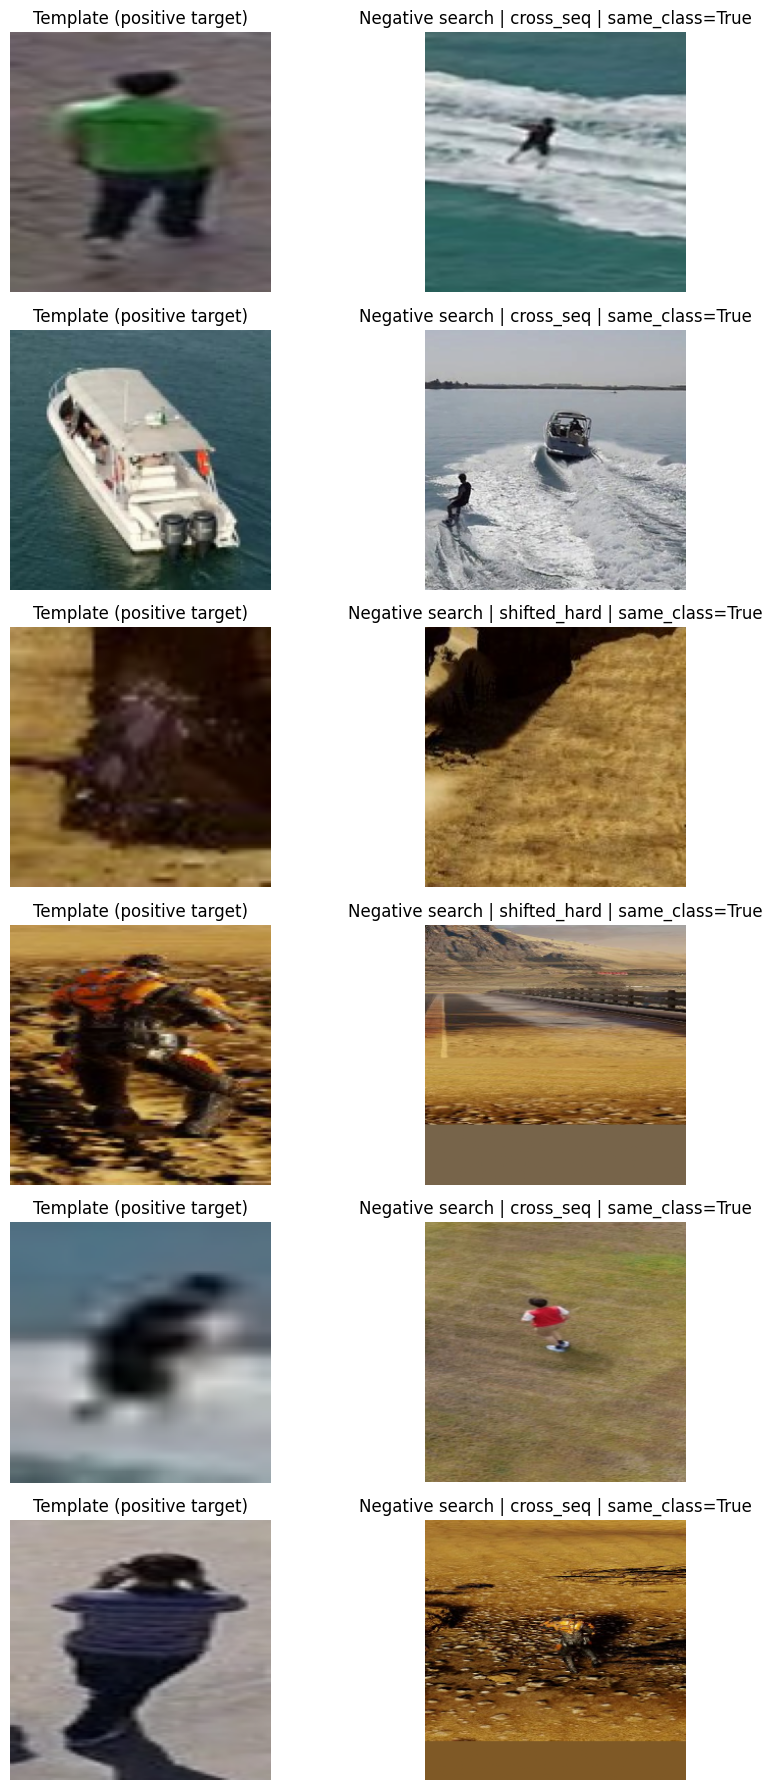

In [20]:
# Visualize a few sampled negatives (template vs negative search)
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def denorm_chw_tensor(t):
    arr = t.detach().cpu().numpy().transpose(1, 2, 0)
    arr = (arr * STD + MEAN)
    return np.clip(arr, 0.0, 1.0)

K = 6
fig, axes = plt.subplots(K, 2, figsize=(10, 3 * K))

for i in range(K):
    sample = robust_negative_sample(neg_dataset)
    meta = neg_dataset._dbg_samples[-1] if neg_dataset._dbg_samples else {}

    t_img = denorm_chw_tensor(sample['template'])
    s_img = denorm_chw_tensor(sample['search'])

    axes[i, 0].imshow(t_img)
    axes[i, 0].set_title('Template (positive target)')
    axes[i, 1].imshow(s_img)
    axes[i, 1].set_title(
        f"Negative search | {meta.get('strategy')} | same_class={meta.get('same_class')}"
    )

    axes[i, 0].axis('off')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()
